IMPORTS

In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transform
import matplotlib.pyplot as plt
import pandas as pd
import pickle

INPUTS

In [14]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inputsize = 784
numclasses=10
numepochs=15
batchsize=100
learningrate=0.001

DATASET LOADING

In [15]:
train_dataset=torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform.ToTensor(), download=True)
test_dataset=torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform.ToTensor(), download=True)
train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batchsize,shuffle=True)
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batchsize,shuffle=False)


MODEL DEFINITION

In [16]:
class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


LOSS FUNCTION AND OPTIMISER

In [17]:
model = CNNNet().to(device)

criterion=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learningrate)

train_losses = []
train_accs = []

val_losses=[]
val_accs=[]


ntotalsteps=len(train_loader)


TRAINING LOOP

In [18]:
for epoch in range(numepochs):


    running_loss = 0.0  #for calculating loss during training
    correct=0  #for calculating accuracy during training
    total=0

    model.train()

    for i,(images,labels) in enumerate(train_loader):

     images=images.to(device)
     labels=labels.to(device)

     outputs=model(images)

     loss=criterion(outputs,labels)
     optimizer.zero_grad()

     loss.backward()
     optimizer.step()

     running_loss += loss.item()

     _, predicted = torch.max(outputs, 1)
     total += labels.size(0)
     correct += (predicted == labels).sum().item()



    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    train_acc = 100 * correct / total
    train_accs.append(train_acc)


    #VALIDATION
    model.eval()

    val_loss = 0  #for calculating loss during validation
    correct = 0  #for calculating accuracy during validation
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(test_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{numepochs}")
    print(f"Train Loss: {train_losses[epoch]:.4f}")
    print(f"Train Accuracy: {train_accs[epoch]:.2f}%")
    print(f"Validation Loss: {val_losses[epoch]:.4f}")
    print(f"Validation Accuracy: {val_accs[epoch]:.2f}%\n")


Epoch 1/15
Train Loss: 0.5240
Train Accuracy: 81.06%
Validation Loss: 0.3525
Validation Accuracy: 87.25%

Epoch 2/15
Train Loss: 0.3327
Train Accuracy: 87.98%
Validation Loss: 0.3240
Validation Accuracy: 88.02%

Epoch 3/15
Train Loss: 0.2840
Train Accuracy: 89.70%
Validation Loss: 0.2713
Validation Accuracy: 90.13%

Epoch 4/15
Train Loss: 0.2532
Train Accuracy: 90.72%
Validation Loss: 0.2580
Validation Accuracy: 90.57%

Epoch 5/15
Train Loss: 0.2322
Train Accuracy: 91.43%
Validation Loss: 0.2399
Validation Accuracy: 91.08%

Epoch 6/15
Train Loss: 0.2115
Train Accuracy: 92.21%
Validation Loss: 0.2339
Validation Accuracy: 91.49%

Epoch 7/15
Train Loss: 0.1955
Train Accuracy: 92.75%
Validation Loss: 0.2300
Validation Accuracy: 91.70%

Epoch 8/15
Train Loss: 0.1805
Train Accuracy: 93.33%
Validation Loss: 0.2260
Validation Accuracy: 91.75%

Epoch 9/15
Train Loss: 0.1661
Train Accuracy: 93.86%
Validation Loss: 0.2295
Validation Accuracy: 92.03%

Epoch 10/15
Train Loss: 0.1518
Train Accuracy:

PLOTTING LOSS AND ACCURACY

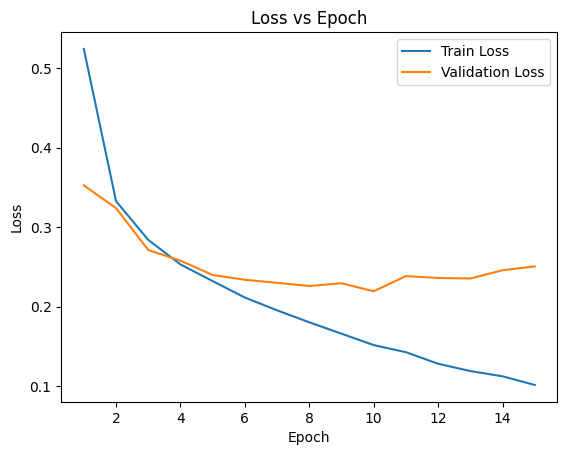

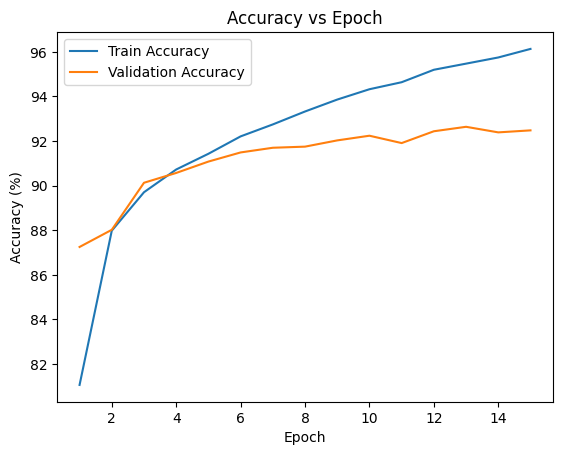

In [19]:
epochs = range(1, numepochs + 1)

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.savefig('loss_plot.png')
plt.show()


plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.savefig('accuracy_plot.png')
plt.show()


TEST LOOP

In [20]:
predictions_list=[]

model.eval()
with torch.no_grad():
    ncorrect=0
    nsamples=0
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)

        _,predictions=torch.max(outputs,1)
        predictions_list.extend(predictions.cpu().tolist())

        nsamples+=labels.shape[0]
        ncorrect+=(predictions==labels).sum().item()

    acc=100.0 * ncorrect / nsamples
    print(f'Overall accuracy for test loop={acc}')


Overall accuracy for test loop=92.48


SUBMISSION.CSV

In [21]:
submission = pd.DataFrame({
    'Id' : range(len(predictions_list)),
    'Label' : predictions_list
})

submission.to_csv('submission.csv',index=False)
print("submission.csv created successfully")


submission.csv created successfully


SAVING WEIGHTS

In [22]:
with open('fashion_mnist_weights.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("Weights saved! successfully using pickle")

Weights saved! successfully using pickle


In [23]:
torch.save(model.state_dict(), "fashion_mnist_model.pth")